# Exercise 07: Heatmap

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

conn = sqlite3.connect('../data/checking-logs.sqlite')


## Analyzing users 

In [2]:
df = pd.read_sql("""
SELECT uid, timestamp
FROM checker
WHERE uid LIKE 'user_%'
""", conn)

conn.close()

## Plotting Heatmap

C:\Users\Asror\AppData\Local\Temp\ipykernel_7472\1131905090.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot1 = df.pivot_table(index='weekday', columns='uid', aggfunc='size', fill_value=0)


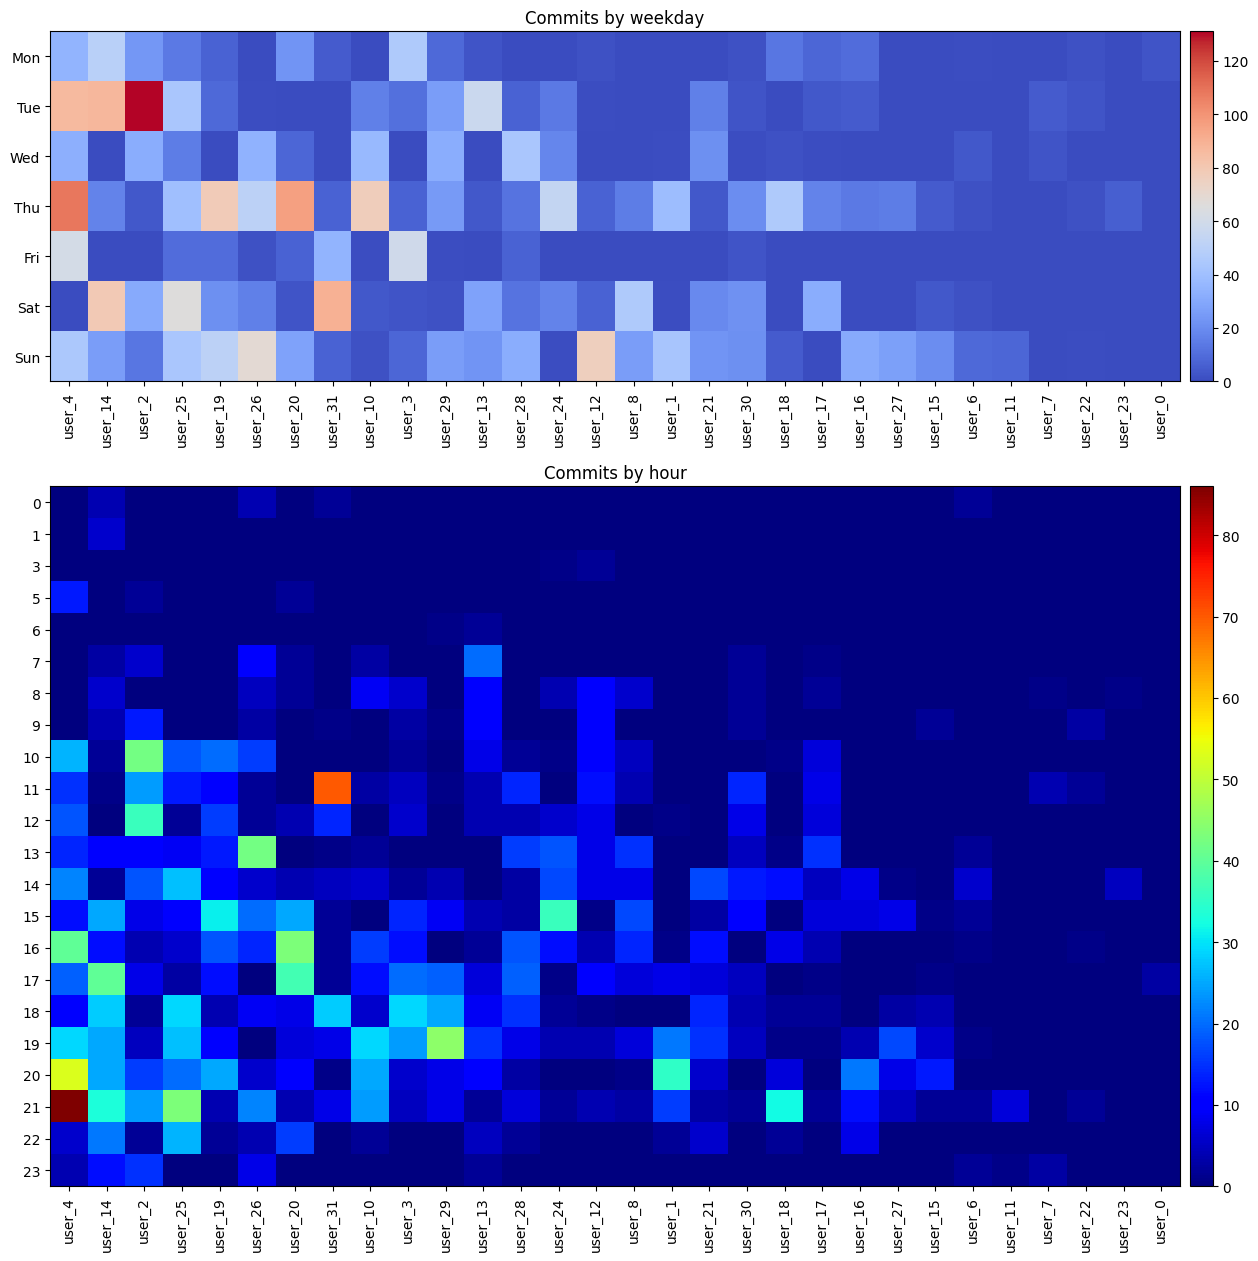

In [ ]:
# time features
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['weekday'] = df['timestamp'].dt.day_name().str[:3]
df['hour'] = df['timestamp'].dt.hour

# ✅ order weekdays (IMPORTANT)
week_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df['weekday'] = pd.Categorical(df['weekday'], categories=week_order, ordered=True)

# pivot tables
pivot1 = df.pivot_table(index='weekday', columns='uid', aggfunc='size', fill_value=0)
pivot2 = df.pivot_table(index='hour', columns='uid', aggfunc='size', fill_value=0)

# sort users by total commits
pivot1 = pivot1[pivot1.sum().sort_values(ascending=False).index]
pivot2 = pivot2[pivot2.sum().sort_values(ascending=False).index]

fig, axes = plt.subplots(
    2, 1,
    figsize=(15, 15),
    gridspec_kw={'height_ratios': [1, 2]}  # bottom is 2x bigger
)
# weekday heatmap
im1 = axes[0].imshow(pivot1, aspect='auto', cmap='coolwarm')
axes[0].set_title('Commits by weekday')
axes[0].set_yticks(range(len(pivot1.index)))
axes[0].set_yticklabels(pivot1.index)
axes[0].set_xticks(range(len(pivot1.columns)))
axes[0].set_xticklabels(pivot1.columns, rotation=90)

divider1 = make_axes_locatable(axes[0])
cax1 = divider1.append_axes("right", size="2%", pad=0.1)
plt.colorbar(im1, cax=cax1)

# hour heatmap
im2 = axes[1].imshow(pivot2, aspect='auto', cmap='jet')
axes[1].set_title('Commits by hour')
axes[1].set_yticks(range(len(pivot2.index)))
axes[1].set_yticklabels(pivot2.index)
axes[1].set_xticks(range(len(pivot2.columns)))
axes[1].set_xticklabels(pivot2.columns, rotation=90)

divider2 = make_axes_locatable(axes[1])
cax2 = divider2.append_axes("right", size="2%", pad=0.1)
plt.colorbar(im2, cax=cax2)

plt.show()

Which user has the most commits on Tuesday? The answer is user_2

Which user has the most commits on Thursday? The answer is user_10.

On which weekday do users not like to make a lot of commits? The answer is Friday

Which user made the largest number of commits at which hour? The answer is user_4, 21.